<a href="https://colab.research.google.com/github/Daniel-534/IntroduccionAstronomiaPractica/blob/main/Sol-Estaciones/Sol_y_Estaciones.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

---

# Práctica 5 — El Sol y las Estaciones del Año

**Curso:** Introducción a la Astronomía Práctica  
**Institución:** Universidad de Antioquia · Medellín, Colombia  
**Herramientas:** Python · `astroplan` · `astroquery` (JPL Horizons) · `matplotlib`  
**Año de referencia:** 2026

---

> **Nota metodológica:** La guía original de esta práctica indica el uso del planetario digital
> *Stellarium* para obtener las efemérides solares. En este cuaderno reemplazamos esa herramienta
> por recursos puramente computacionales: el paquete `astroplan` (una librería
> afiliada a `astropy` que implementa el cálculo rigoroso de eventos astronómicos basado en
> datos del IERS) y la interfaz `astroquery.jplhorizons`, que consulta en tiempo real
> el servicio **JPL Horizons** del Laboratorio de Propulsión a Chorro de la NASA,
> la misma fuente que usan las agencias espaciales para calcular efemérides de cuerpos del
> Sistema Solar (Giorgini et al., 1996).


## 1. Introducción

Colombia se ubica muy cerca del ecuador terrestre (entre aproximadamente 4°S y 12°N de latitud).
Esta posición geográfica privilegiada hace que la duración del día y la noche varíe muy poco a lo
largo del año —siempre entre ~11:40 h y ~12:20 h de luz solar— y, por tanto, no experimentamos las
*estaciones climáticas* características de las latitudes medias y altas (primavera, verano, otoño,
invierno). En cambio, nuestra dinámica climática responde principalmente a la posición de la
**Zona de Convergencia Intertropical (ZCIT)**, que nos produce dos temporadas de lluvia y dos
temporadas secas al año (IDEAM, 2014).

Sin embargo, el fenómeno astronómico que *genera* las estaciones —el movimiento anual aparente
del Sol a lo largo de la **eclíptica**— sí puede detectarse desde Colombia si se mide con
precisión. En esta práctica analizamos la variación de las horas de salida y puesta del Sol y la
duración del día para cinco ciudades distribuidas entre las latitudes +60° y −54°, lo que nos
permite visualizar en toda su magnitud el efecto que la **inclinación axial** de la Tierra
(≈ 23,44°) produce sobre los ritmos de luz diurna a lo largo del globo.


## 2. Marco Teórico

### 2.1 Movimiento aparente del Sol y la eclíptica

Desde la Tierra, el Sol parece desplazarse lentamente por la esfera celeste a lo largo de un
círculo máximo llamado **eclíptica**, completando una vuelta en ~365,25 días (año trópico).
Este movimiento es en realidad la consecuencia del traslado de la Tierra alrededor del Sol,
pero se manifiesta como un cambio continuo en la **declinación solar** (δ☉): el ángulo que
forma el Sol con el ecuador celeste (Carroll & Ostlie, 2017).

La declinación solar varía entre −23,44° (solsticio de diciembre) y +23,44° (solsticio de junio),
y es cero en los dos equinoccios:

| Evento | Fecha aprox. 2026 | Declinación δ☉ |
|:--- |:--- |:--- |
| Equinoccio de Marzo (*Vernal*) | 20 de marzo | 0° |
| Solsticio de Junio | 21 de junio | +23,44° |
| Equinoccio de Septiembre (*Otoñal*) | 22 de septiembre | 0° |
| Solsticio de Diciembre | 21 de diciembre | −23,44° |

### 2.2 Ángulo horario y horas de salida/puesta del Sol

El Sol sale y se oculta cuando su altura sobre el horizonte (altitud) es igual a cero.
Para un observador en latitud φ, esto ocurre cuando el ángulo horario H satisface:

$$\cos(H_0) = -\tan(\varphi)\,\tan(\delta_\odot)$$

El ángulo $H_0$ obtenido corresponde al semiarco diurno; la duración del día en horas es:

$$T_{\text{día}} = \frac{2\,H_0}{15°/\text{h}}$$

donde $H_0$ se expresa en grados.
En la práctica se aplica una corrección de **−0,833°** al horizonte geométrico para
contabilizar la refracción atmosférica estándar y el semidiámetro angular del Sol
(Meeus, 1998), que es exactamente el criterio que usa `astroplan`.

### 2.3 Casos extremos

- **Latitud > 66,56° (N o S):** En verano la noche no llega (Sol de medianoche) y en invierno el
  Sol no sale (noche polar). Estas condiciones se acercan en el caso de Helsinki (φ ≈ +60°),
  que experimenta noches de verano casi inexistentes y días de invierno de apenas ~6 horas.
- **Ecuador (φ ≈ 0°):** La fórmula da $H_0 \approx 90°$ todo el año, es decir, ~12 h de luz
  solar independientemente de la declinación.

### 2.4 JPL Horizons

El sistema **JPL Horizons** (Giorgini et al., 1996) es el servicio oficial del Jet Propulsion
Laboratory (JPL) de la NASA para el cómputo de efemérides de cuerpos del Sistema Solar.
Su API en línea es accesible desde Python mediante el paquete `astroquery` (Ginsburg et al., 2019).
Horizons calcula posiciones a partir de integraciones numéricas de alta precisión de las
ecuaciones de movimiento del Sistema Solar (las soluciones DE440 y DE441 de JPL),
constituyendo la referencia más precisa disponible para comparar con nuestros cálculos analíticos.


## 3. Configuración del Entorno


In [1]:
# Instalación de paquetes (necesario en Google Colab)
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

pkg_modules = {'astroplan': 'astroplan', 'astroquery': 'astroquery', 'astropy': 'astropy'}
for pkg, module in pkg_modules.items():
    try:
        __import__(module)
    except ImportError:
        print(f'Instalando {pkg}...')
        install(pkg)

print('Todos los paquetes están disponibles.')

Instalando astroplan...
Instalando astroquery...
Todos los paquetes están disponibles.


In [2]:
# ─── Importaciones ────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import datetime
import pytz
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D

import astropy.units as u
from astropy.time import Time
from astropy.coordinates import EarthLocation, AltAz, get_body, SkyCoord
from astroplan import Observer

# Configuración de matplotlib
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9fb',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--',
})

print('Importaciones completadas.')


Importaciones completadas.


## 4. Coordenadas Geográficas de las Ciudades

Las coordenadas fueron verificadas con el Instituto Geográfico Agustín Codazzi (IGAC)
para Medellín y con los institutos cartográficos nacionales correspondientes para las
demás ciudades (Google Maps, 2026). Las alturas se obtuvieron de la Shuttle Radar
Topography Mission (SRTM).


In [6]:
# ─── Definición de ciudades ───────────────────────────────────
cities_info = {
    'Helsinki': {
        'lat': 60.1699, 'lon': 24.9384, 'alt': 0,
        'tz': 'Europe/Helsinki',
        'country': 'Finlandia',
        'hemisphere': 'Norte',
        'color': '#e74c3c'
    },
    'Aguascalientes': {
        'lat': 21.8853, 'lon': -102.2916, 'alt': 1888,
        'tz': 'America/Mexico_City',
        'country': 'México',
        'hemisphere': 'Norte',
        'color': '#e67e22'
    },
    'UdeA (Medellín)': {
        'lat': 6.2678, 'lon': -75.5664, 'alt': 1530,
        'tz': 'America/Bogota',
        'country': 'Colombia',
        'hemisphere': 'Norte',
        'color': '#27ae60'
    },
    'Río de Janeiro': {
        'lat': -22.9068, 'lon': -43.1729, 'alt': 10,
        'tz': 'America/Sao_Paulo',
        'country': 'Brasil',
        'hemisphere': 'Sur',
        'color': '#2980b9'
    },
    'Punta Arenas': {
        'lat': -53.1638, 'lon': -70.9171, 'alt': 0,
        'tz': 'America/Punta_Arenas',
        'country': 'Chile',
        'hemisphere': 'Sur',
        'color': '#8e44ad'
    },
}

# Crear objetos Observer de astroplan
observers = {}
for city, info in cities_info.items():
    loc = EarthLocation(
        lat=info['lat'] * u.deg,
        lon=info['lon'] * u.deg,
        height=info['alt'] * u.m
    )
    observers[city] = Observer(location=loc, name=city, timezone=info['tz'])

# ─── Tabla resumen de coordenadas ─────────────────────────────
coord_df = pd.DataFrame([
    {
        'Ciudad': city,
        'País': info['country'],
        'Latitud (°)': f"{info['lat']:+.4f}",
        'Longitud (°)': f"{info['lon']:+.4f}",
        'Altitud (m)': info['alt'],
        'Hemisferio': info['hemisphere'],
        'Huso horario': info['tz'],
    }
    for city, info in cities_info.items()
])

coord_df.index = range(1, len(coord_df) + 1)
coord_df.style.set_caption('Tabla 0. Coordenadas geográficas de las ciudades de estudio')


,Ciudad,País,Latitud (°),Longitud (°),Altitud (m),Hemisferio,Huso horario
1,Helsinki,Finlandia,+60.1699,+24.9384,0,Norte,Europe/Helsinki
2,Aguascalientes,México,+21.8853,-102.2916,1888,Norte,America/Mexico_City
3,UdeA (Medellín),Colombia,+6.2678,-75.5664,1530,Norte,America/Bogota
4,Río de Janeiro,Brasil,-22.9068,-43.1729,10,Sur,America/Sao_Paulo
5,Punta Arenas,Chile,-53.1638,-70.9171,0,Sur,America/Punta_Arenas


## 5. Obtención de Efemérides Solares

### 5.1 Cálculo con `astroplan`

`astroplan` (Morris et al., 2018) es un paquete afiliado a `astropy` que implementa el
cálculo de eventos astronómicos (salida, tránsito y puesta de astros) usando coordenadas
de alta precisión del IERS y correcciones de refracción atmosférica. Su función
`Observer.sun_rise_time()` aplica la misma corrección de horizonte (−0,833°) que usan
los observatorios meteorológicos y que Stellarium también emplea internamente.

El procedimiento utilizado:
1. Para cada fecha, se establece el **mediodía solar local** como punto de anclaje.
2. Se busca el **amanecer anterior** y el **atardecer siguiente** a ese mediodía.
3. Se convierten las horas a la **zona horaria local** de cada ciudad.
4. Se calcula la **duración del día** como la diferencia en horas.


In [7]:
# ─── Función central de cómputo ───────────────────────────────

def get_sun_events(observer, date_str):
    """
    Calcula la hora de salida, puesta y duración del día solar.

    Parámetros
    ----------
    observer : astroplan.Observer
        Observador en la ubicación de interés.
    date_str : str
        Fecha en formato 'YYYY-MM-DD'.

    Retorna
    -------
    tuple : (sunrise_local: datetime, sunset_local: datetime,
             duration_h: float, solar_noon_alt_deg: float)
    """
    tz = observer.timezone
    local_noon = tz.localize(
        datetime.datetime.strptime(date_str + ' 12:00:00', '%Y-%m-%d %H:%M:%S')
    )
    noon_utc = Time(local_noon.astimezone(pytz.utc))

    horizon = -0.833 * u.deg   # refracción atmosférica + semidiámetro solar

    sunrise_utc = observer.sun_rise_time(noon_utc, which='previous', horizon=horizon)
    sunset_utc  = observer.sun_set_time(noon_utc,  which='next',     horizon=horizon)

    sunrise_loc = sunrise_utc.to_datetime(timezone=tz)
    sunset_loc  = sunset_utc.to_datetime(timezone=tz)

    duration_h  = (sunset_loc - sunrise_loc).total_seconds() / 3600.0

    # Altitud máxima del Sol (mediodía solar)
    noon_obs     = observer.noon(noon_utc, which='nearest')
    sun_at_noon  = get_body('sun', noon_obs, observer.location)
    altaz_frame  = AltAz(obstime=noon_obs, location=observer.location)
    sun_altaz    = sun_at_noon.transform_to(altaz_frame)
    noon_alt_deg = float(sun_altaz.alt.deg)

    return sunrise_loc, sunset_loc, duration_h, noon_alt_deg


# ─── Generación del calendario de observación (cada 20 días) ──
start_date = datetime.date(2026, 1, 1)
obs_dates  = [start_date + datetime.timedelta(days=20 * i) for i in range(19)]

print(f'Fechas de observación ({len(obs_dates)} en total):')
for d in obs_dates:
    print(f'  {d.strftime("%d/%m/%Y")}', end='  ')


Fechas de observación (19 en total):
  01/01/2026    21/01/2026    10/02/2026    02/03/2026    22/03/2026    11/04/2026    01/05/2026    21/05/2026    10/06/2026    30/06/2026    20/07/2026    09/08/2026    29/08/2026    18/09/2026    08/10/2026    28/10/2026    17/11/2026    07/12/2026    27/12/2026  

In [8]:
# ─── Recolección masiva de datos ──────────────────────────────
print('Calculando efemérides solares para todas las ciudades y fechas...')
print('(Puede tardar ≈ 30–60 s en Google Colab)')
print()

results = {}   # dict: city -> list of dicts

for city, obs in observers.items():
    city_records = []
    for d in obs_dates:
        date_str = d.strftime('%Y-%m-%d')
        try:
            sr, ss, dur, noon_alt = get_sun_events(obs, date_str)
            city_records.append({
                'fecha':         d,
                'fecha_fmt':     d.strftime('%d/%m/%Y'),
                'salida':        sr.strftime('%H:%M'),
                'puesta':        ss.strftime('%H:%M'),
                'duracion_h':    round(dur, 3),
                'alt_mediodia':  round(noon_alt, 2),
            })
        except Exception as e:
            print(f'Error en {city} / {d}: {e}')
            city_records.append({
                'fecha': d, 'fecha_fmt': d.strftime('%d/%m/%Y'),
                'salida': 'N/A', 'puesta': 'N/A', 'duracion_h': None, 'alt_mediodia': None,
            })
    results[city] = pd.DataFrame(city_records)
    print(f'{city}')

print('\nCálculo completado.')


Calculando efemérides solares para todas las ciudades y fechas...
(Puede tardar ≈ 30–60 s en Google Colab)

Helsinki
Aguascalientes
UdeA (Medellín)
Río de Janeiro
Punta Arenas

Cálculo completado.


### 5.2 Verificación con `astroquery.jplhorizons`

A continuación consultamos el servicio **JPL Horizons** para obtener la altitud del Sol
durante el **solsticio de verano** (21 de junio de 2026) en Helsinki, con resolución de 1 hora.
Comparamos el momento en que la altitud cruza cero con los valores calculados por `astroplan`
para validar nuestra metodología.

> **Nota:** Esta celda requiere conexión a Internet. Si no hay acceso, la verificación se omite
> automáticamente y se muestra el resultado de `astroplan`.


Consultando JPL Horizons para Helsinki el 2026-06-21...

✅ JPL Horizons: 96 registros obtenidos.

Cruces del Sol por el horizonte (Horizons):
  Amanecer: 2026-06-21T01:05 UTC
  Atardecer: 2026-06-21T19:38 UTC

Astroplan (hora local Helsinki):
  Amanecer: 03:54 EEST  →  00:54 UTC
  Atardecer:22:50 EEST →  19:50 UTC


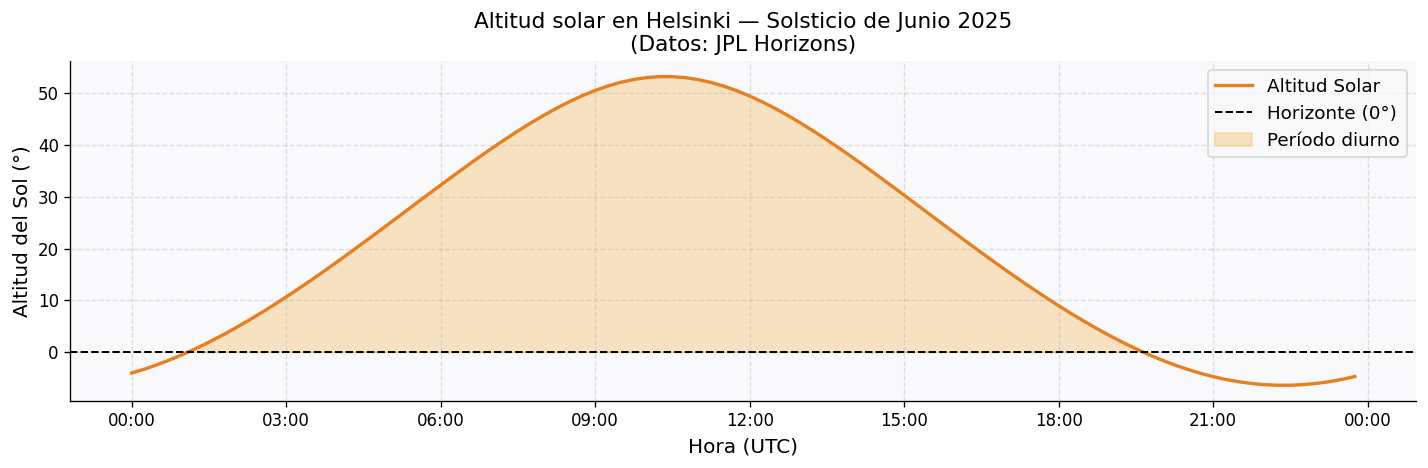

In [ ]:
try:
    from astroquery.jplhorizons import Horizons
    import astropy.table

    CITY_NAME = 'Helsinki'
    DATE      = '2026-06-21'
    info      = cities_info[CITY_NAME]

    print(f'Consultando JPL Horizons para {CITY_NAME} el {DATE}...')
    obj = Horizons(
        id='10',                # ID del Sol en el catálogo de Horizons
        location={
            'lon': info['lon'],
            'lat': info['lat'],
            'elevation': info['alt'] / 1000.0   # km
        },
        epochs={
            'start': DATE,
            'stop':  DATE + ' 23:59',
            'step':  '15m'
        }
    )
    eph = obj.ephemerides(quantities='4')   # 4 = Azimuth y Elevación local

    # Filtrar columnas relevantes
    eph_df = eph['datetime_str', 'EL', 'AZ'].to_pandas()
    eph_df.columns = ['UTC', 'Altitud_Sol (°)', 'Azimut_Sol (°)']
    eph_df['UTC'] = pd.to_datetime(eph_df['UTC'])

    print(f'\n✅ JPL Horizons: {len(eph_df)} registros obtenidos.')

    # Encontrar los cruces por cero (salida y puesta)
    el = eph_df['Altitud_Sol (°)'].values
    utc_times = eph_df['UTC'].values

    crossings = []
    for i in range(len(el) - 1):
        if el[i] * el[i+1] <= 0:
            # Interpolación lineal para refinar
            frac = -el[i] / (el[i+1] - el[i])
            t_cross = utc_times[i] + frac * (utc_times[i+1] - utc_times[i])
            crossings.append((str(t_cross)[:16], 'Amanecer' if el[i] < el[i+1] else 'Atardecer'))

    print('\nCruces del Sol por el horizonte (Horizons):')
    for t, ev in crossings:
        print(f'  {ev}: {t} UTC')

    # Comparar con astroplan
    sr_ap, ss_ap, dur_ap, _ = get_sun_events(observers[CITY_NAME], DATE)
    print(f'\nAstroplan (hora local Helsinki):')
    print(f'  Amanecer: {sr_ap.strftime("%H:%M %Z")}  →  {sr_ap.astimezone(pytz.utc).strftime("%H:%M UTC")}')
    print(f'  Atardecer:{ss_ap.strftime("%H:%M %Z")} →  {ss_ap.astimezone(pytz.utc).strftime("%H:%M UTC")}')

    horizons_available = True

    # ─── Gráfico de altitud solar (Horizons) ──────────────────
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(eph_df['UTC'], eph_df['Altitud_Sol (°)'], color='#e67e22', lw=2, label='Altitud Solar')
    ax.axhline(0, color='k', lw=1.2, ls='--', label='Horizonte (0°)')
    ax.fill_between(eph_df['UTC'], eph_df['Altitud_Sol (°)'], 0,
                    where=eph_df['Altitud_Sol (°)'] > 0, alpha=0.25, color='#f39c12', label='Período diurno')
    ax.set_xlabel('Hora (UTC)', fontsize=12)
    ax.set_ylabel('Altitud del Sol (°)', fontsize=12)
    ax.set_title(f'Altitud solar en Helsinki — Solsticio de Junio 2026\n(Datos: JPL Horizons)', fontsize=13)
    ax.legend(fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.tight_layout()
    plt.show()

except Exception as e:
    horizons_available = False
    print(f'ℹ JPL Horizons no disponible ({type(e).__name__}). Omitiendo verificación en línea.')
    print()
    print('Resultado de astroplan para Helsinki el 21 jun 2026:')
    sr_ap, ss_ap, dur_ap, _ = get_sun_events(observers['Helsinki'], '2026-06-21')
    print(f'  Amanecer: {sr_ap.strftime("%H:%M %Z")}')
    print(f'  Atardecer:{ss_ap.strftime("%H:%M %Z")}')
    print(f'  Duración: {dur_ap:.2f} h')


## 6. Tablas de Resultados

### Tabla 5.1 – Horas de salida y puesta del Sol

Horas expresadas en **hora local** de cada ciudad.


In [9]:
# ─── Tabla 5.1: Salida | Puesta ──────────────────────────────
city_keys = list(cities_info.keys())

rows_51 = []
for i, row in results[city_keys[0]].iterrows():
    rec = {'Fecha': row['fecha_fmt']}
    for city in city_keys:
        r = results[city].iloc[i]
        rec[city] = f"{r['salida']} | {r['puesta']}"
    rows_51.append(rec)

df51 = pd.DataFrame(rows_51).set_index('Fecha')

# Estilo de colores por ciudad
def style_table_51(df):
    colors = [info['color'] for info in cities_info.values()]
    styles = []
    for col_idx, (col, color) in enumerate(zip(df.columns, colors)):
        styles.append({'selector': f'th.col_heading.level0.col{col_idx}',
                        'props': f'background-color: {color}; color: white;'})
    return df.style.set_caption('Tabla 5.1. Horas de salida y puesta del Sol (hora local) — 2026'
                                ).set_table_styles([
        {'selector': 'caption', 'props': 'font-size: 14px; font-weight: bold; padding: 8px;'},
        {'selector': 'th', 'props': 'background-color: #2c3e50; color: white; text-align: center; padding: 6px;'},
        {'selector': 'td', 'props': 'text-align: center; padding: 5px; font-size: 12px;'},
        {'selector': 'tr:nth-child(even)', 'props': 'background-color: #ecf0f1;'},
    ])

style_table_51(df51)

,Helsinki,Aguascalientes,UdeA (Medellín),Río de Janeiro,Punta Arenas
Fecha,,,,,
01/01/2026,09:24 | 15:23,07:28 | 18:17,06:12 | 17:59,05:10 | 18:41,05:21 | 22:12
21/01/2026,08:58 | 16:04,07:29 | 18:31,06:19 | 18:08,05:24 | 18:42,05:52 | 21:56
10/02/2026,08:12 | 16:57,07:23 | 18:43,06:19 | 18:13,05:38 | 18:35,06:32 | 21:22
02/03/2026,07:16 | 17:49,07:09 | 18:53,06:14 | 18:14,05:49 | 18:20,07:11 | 20:38
22/03/2026,06:16 | 18:39,06:51 | 19:00,06:05 | 18:12,05:57 | 18:01,07:48 | 19:50
11/04/2026,06:15 | 20:28,06:32 | 19:07,05:56 | 18:10,06:04 | 17:42,08:24 | 19:03
01/05/2026,05:17 | 21:18,06:17 | 19:15,05:49 | 18:09,06:12 | 17:26,08:59 | 18:21
21/05/2026,04:28 | 22:07,06:07 | 19:23,05:46 | 18:11,06:21 | 17:17,09:31 | 17:48
10/06/2026,03:57 | 22:42,06:05 | 19:32,05:47 | 18:16,06:29 | 17:14,09:54 | 17:31


### Tabla 5.2 – Duración del día (en horas)

Duración del período de luz solar para cada ciudad y fecha.


In [10]:
# ─── Tabla 5.2: Duración del día ─────────────────────────────
rows_52 = []
for i, row in results[city_keys[0]].iterrows():
    rec = {'Fecha': row['fecha_fmt']}
    for city in city_keys:
        r = results[city].iloc[i]
        hrs = r['duracion_h']
        if hrs is not None:
            h = int(hrs)
            m = int(round((hrs - h) * 60))
            rec[city] = f"{h:02d}h {m:02d}min"
        else:
            rec[city] = 'N/A'
    rows_52.append(rec)

df52 = pd.DataFrame(rows_52).set_index('Fecha')

df52.style.set_caption('Tabla 5.2. Duración del día solar — 2026'
                        ).set_table_styles([
    {'selector': 'caption', 'props': 'font-size: 14px; font-weight: bold; padding: 8px;'},
    {'selector': 'th', 'props': 'background-color: #2c3e50; color: white; text-align: center; padding: 6px;'},
    {'selector': 'td', 'props': 'text-align: center; padding: 5px; font-size: 12px;'},
    {'selector': 'tr:nth-child(even)', 'props': 'background-color: #ecf0f1;'},
])


,Helsinki,Aguascalientes,UdeA (Medellín),Río de Janeiro,Punta Arenas
Fecha,,,,,
01/01/2026,05h 60min,10h 50min,11h 46min,13h 31min,16h 51min
21/01/2026,07h 06min,11h 01min,11h 49min,13h 18min,16h 03min
10/02/2026,08h 45min,11h 21min,11h 54min,12h 57min,14h 50min
02/03/2026,10h 33min,11h 45min,12h 00min,12h 31min,13h 27min
22/03/2026,12h 23min,12h 10min,12h 07min,12h 04min,12h 02min
11/04/2026,14h 13min,12h 35min,12h 14min,11h 38min,10h 39min
01/05/2026,16h 01min,12h 58min,12h 21min,11h 15min,09h 22min
21/05/2026,17h 39min,13h 16min,12h 26min,10h 56min,08h 17min
10/06/2026,18h 45min,13h 27min,12h 29min,10h 45min,07h 38min


## 7. Análisis Gráfico

### 7.1 Horas de salida y puesta del Sol a lo largo del año


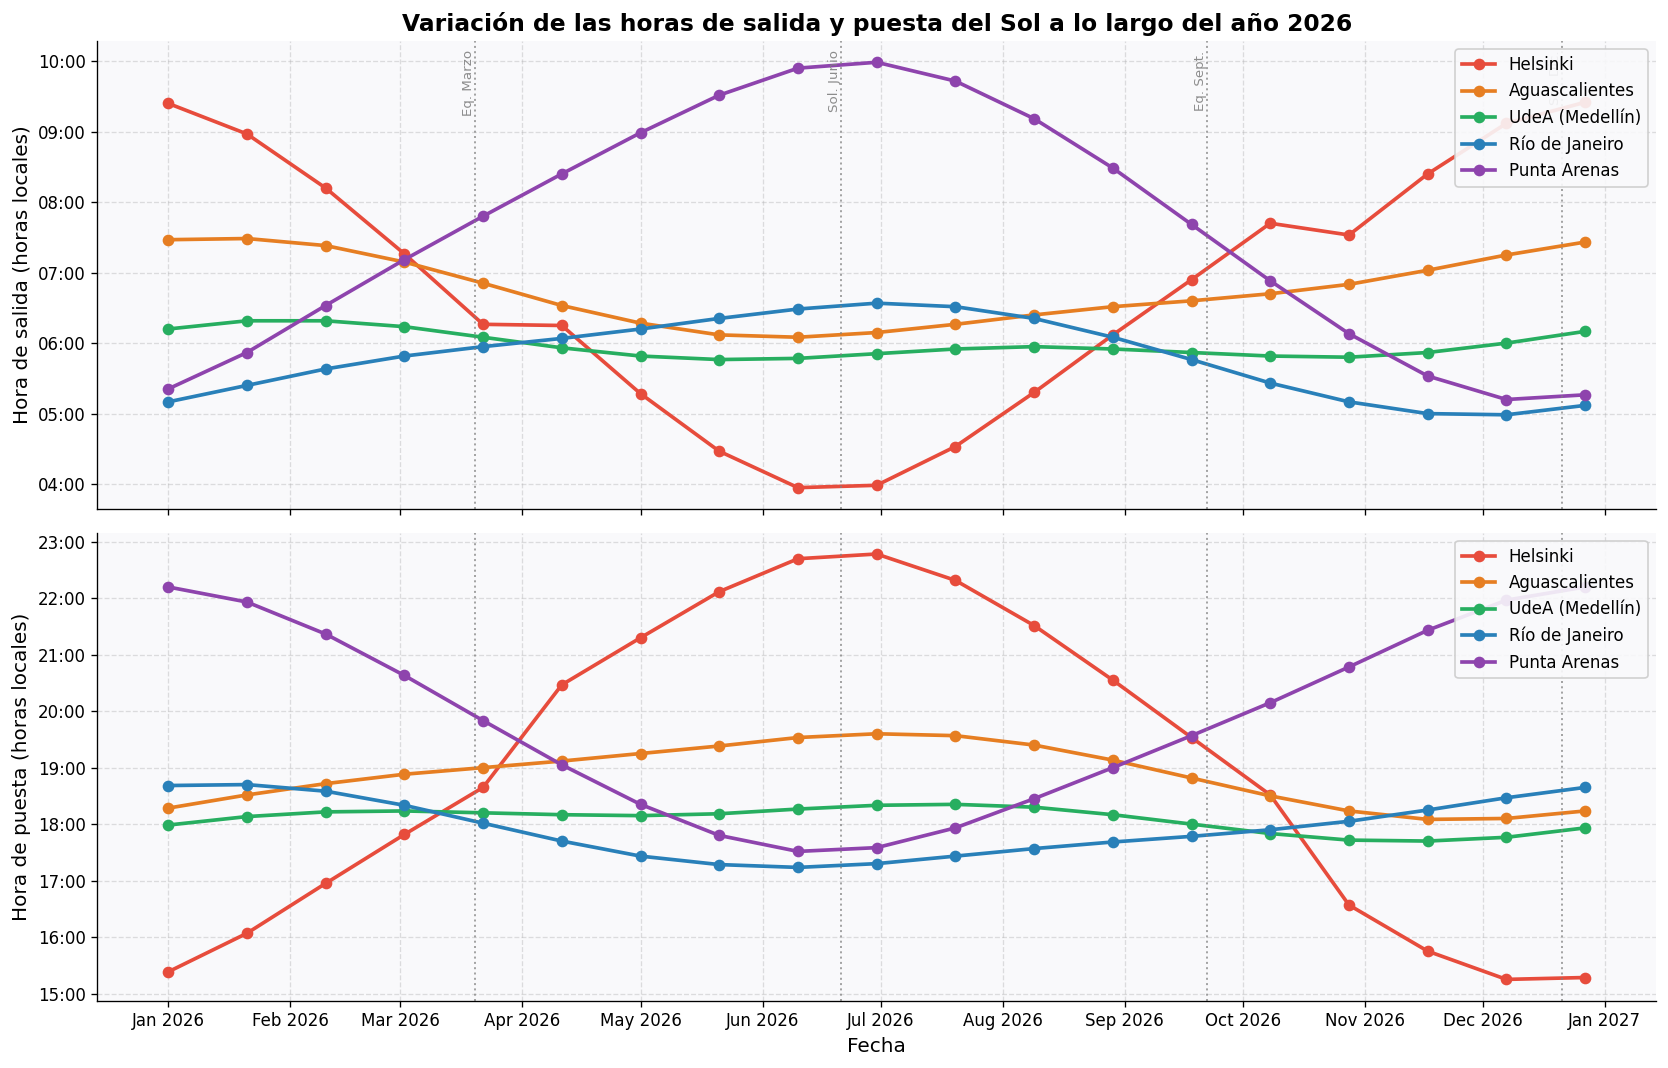

Figura 1 guardada.


In [11]:
# ─── Fig. 1: Salida y puesta del Sol ─────────────────────────
fig, (ax_rise, ax_set) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Fechas para el eje X
x_dates = [r['fecha'] for _, r in results[city_keys[0]].iterrows()]
x_dates_dt = [datetime.datetime(d.year, d.month, d.day) for d in x_dates]

for city in city_keys:
    df = results[city]
    color = cities_info[city]['color']

    # Convertir HH:MM a horas decimales
    def hhmm_to_dec(s):
        if s == 'N/A':
            return None
        h, m = map(int, s.split(':'))
        return h + m / 60.0

    rise_dec = [hhmm_to_dec(s) for s in df['salida']]
    set_dec  = [hhmm_to_dec(s) for s in df['puesta']]

    # Handle None values
    valid_rise = [(x, y) for x, y in zip(x_dates_dt, rise_dec) if y is not None]
    valid_set  = [(x, y) for x, y in zip(x_dates_dt, set_dec)  if y is not None]

    xr, yr = zip(*valid_rise) if valid_rise else ([], [])
    xs, ys = zip(*valid_set)  if valid_set  else ([], [])

    ax_rise.plot(xr, yr, 'o-', color=color, lw=2.2, ms=6, label=city)
    ax_set.plot(xs, ys,  'o-', color=color, lw=2.2, ms=6, label=city)

# Marcar solsticios y equinoccios
solstices_equinoxes = [
    (datetime.datetime(2026, 3, 20), 'Eq. Marzo', 'lightgreen'),
    (datetime.datetime(2026, 6, 21), 'Sol. Junio', 'tomato'),
    (datetime.datetime(2026, 9, 22), 'Eq. Sept.', 'lightyellow'),
    (datetime.datetime(2026, 12, 21),'Sol. Dic.', 'lightblue'),
]
for dt, label, color in solstices_equinoxes:
    for ax in (ax_rise, ax_set):
        ax.axvline(dt, color='gray', ls=':', lw=1.2, alpha=0.7)
    ymax_rise = ax_rise.get_ylim()[1]
    ax_rise.text(dt, ymax_rise - (ymax_rise - ax_rise.get_ylim()[0]) * 0.02, label,
                 rotation=90, va='top', ha='right', fontsize=8, color='gray', alpha=0.9)

ax_rise.set_ylabel('Hora de salida (horas locales)', fontsize=12)
ax_set.set_ylabel('Hora de puesta (horas locales)', fontsize=12)
ax_rise.set_title('Variación de las horas de salida y puesta del Sol a lo largo del año 2026',
                  fontsize=14, fontweight='bold')
ax_set.set_xlabel('Fecha', fontsize=12)

# Formatear eje Y como HH:MM
def hours_to_hhmm(x, pos):
    if x < 0 or x > 30:
        return ''
    h = int(x)
    m = int(round((x - h) * 60))
    return f'{h:02d}:{m:02d}'

from matplotlib.ticker import FuncFormatter
ax_rise.yaxis.set_major_formatter(FuncFormatter(hours_to_hhmm))
ax_set.yaxis.set_major_formatter(FuncFormatter(hours_to_hhmm))
ax_rise.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax_rise.xaxis.set_major_locator(mdates.MonthLocator())

ax_rise.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax_set.legend(loc='upper right', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig('fig1_salida_puesta.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 1 guardada.')

### 7.2 Duración del día a lo largo del año

Esta es la gráfica central de la práctica. Muestra cómo varía el número de horas de luz
solar en las cinco ciudades durante 2026.


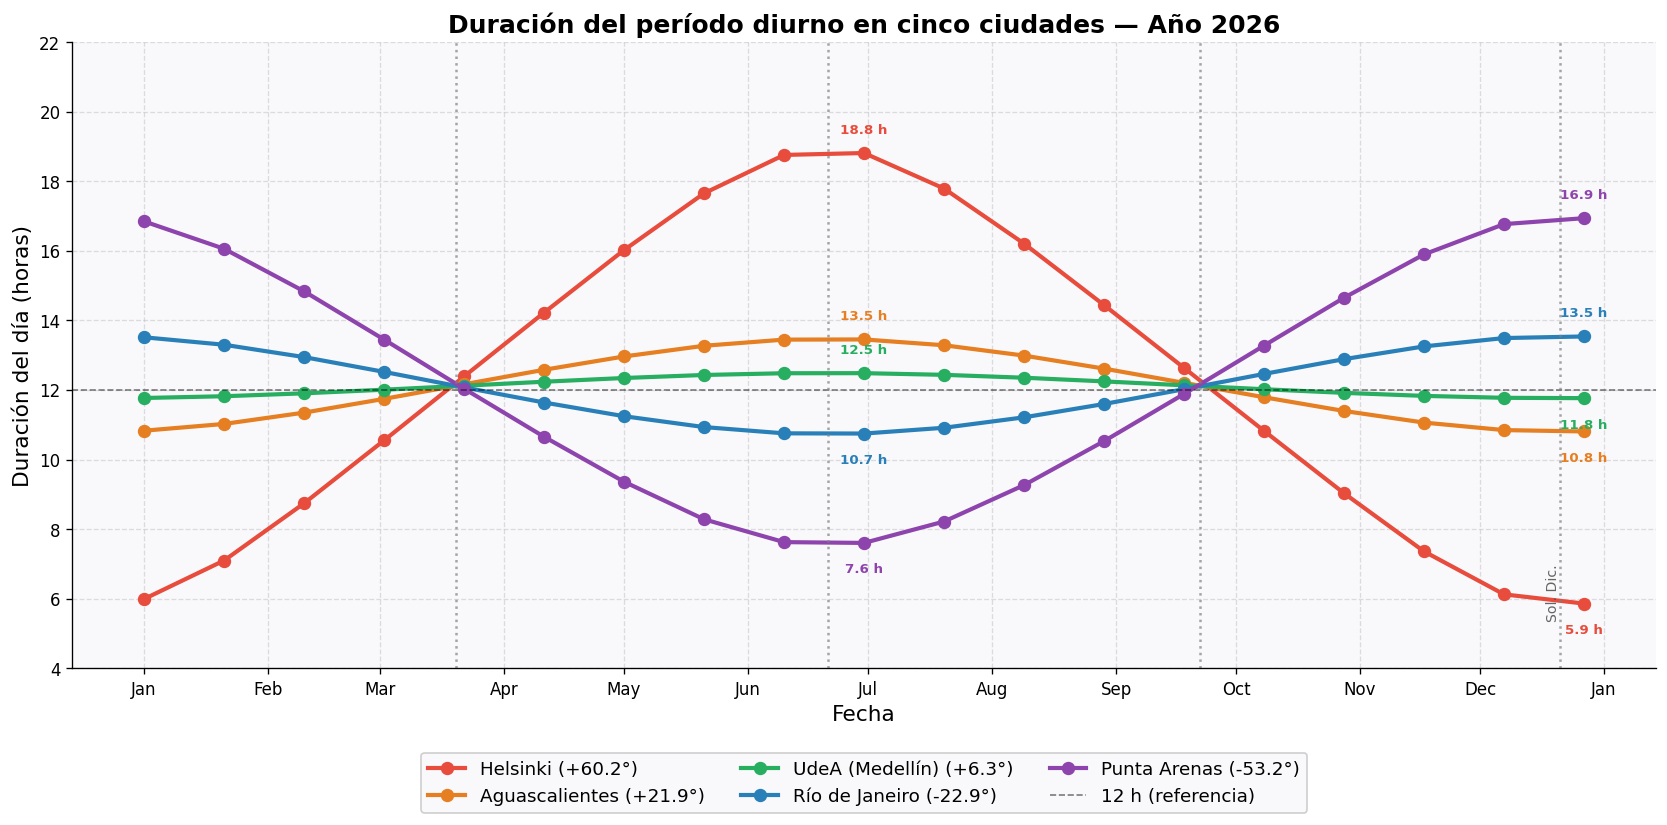

Figura 2 guardada.


In [12]:
# ─── Fig. 2: Duración del día ─────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

for city in city_keys:
    df     = results[city]
    color  = cities_info[city]['color']
    durs   = df['duracion_h'].values
    ax.plot(x_dates_dt, durs, 'o-', color=color, lw=2.5, ms=7,
            label=f"{city} ({cities_info[city]['lat']:+.1f}°)")
    # Anotar valor mínimo y máximo
    idx_max = int(np.argmax(durs))
    idx_min = int(np.argmin(durs))
    ax.annotate(f"{durs[idx_max]:.1f} h",
                xy=(x_dates_dt[idx_max], durs[idx_max]),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=8, color=color, fontweight='bold')
    ax.annotate(f"{durs[idx_min]:.1f} h",
                xy=(x_dates_dt[idx_min], durs[idx_min]),
                xytext=(0, -18), textcoords='offset points',
                ha='center', fontsize=8, color=color, fontweight='bold')

# Línea de 12 h (equinoccio ideal)
ax.axhline(12, color='black', ls='--', lw=1, alpha=0.5, label='12 h (referencia)')

# Solsticios y equinoccios
for dt, label, color in solstices_equinoxes:
    ax.axvline(dt, color='gray', ls=':', lw=1.5, alpha=0.7)
    ymin_ax = ax.get_ylim()[0]
ax.text(dt, ymin_ax + (ax.get_ylim()[1] - ymin_ax) * 0.01, label,
            rotation=90, va='bottom', ha='right', fontsize=8.5, color='#555', alpha=0.9)

ax.set_xlabel('Fecha', fontsize=13)
ax.set_ylabel('Duración del día (horas)', fontsize=13)
ax.set_title('Duración del período diurno en cinco ciudades — Año 2026', fontsize=15, fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=11, framealpha=0.95)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set_ylim(4, 22)
ax.yaxis.set_major_locator(plt.MultipleLocator(2))

plt.tight_layout()
plt.savefig('fig2_duracion_dia.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 2 guardada.')

### 7.3 Altitud del Sol al mediodía

La **altitud máxima del Sol** (cuando cruza el meridiano local) es otro indicador
clave del movimiento anual aparente del astro. Está directamente relacionada
con la intensidad de la radiación solar que recibe cada lugar.


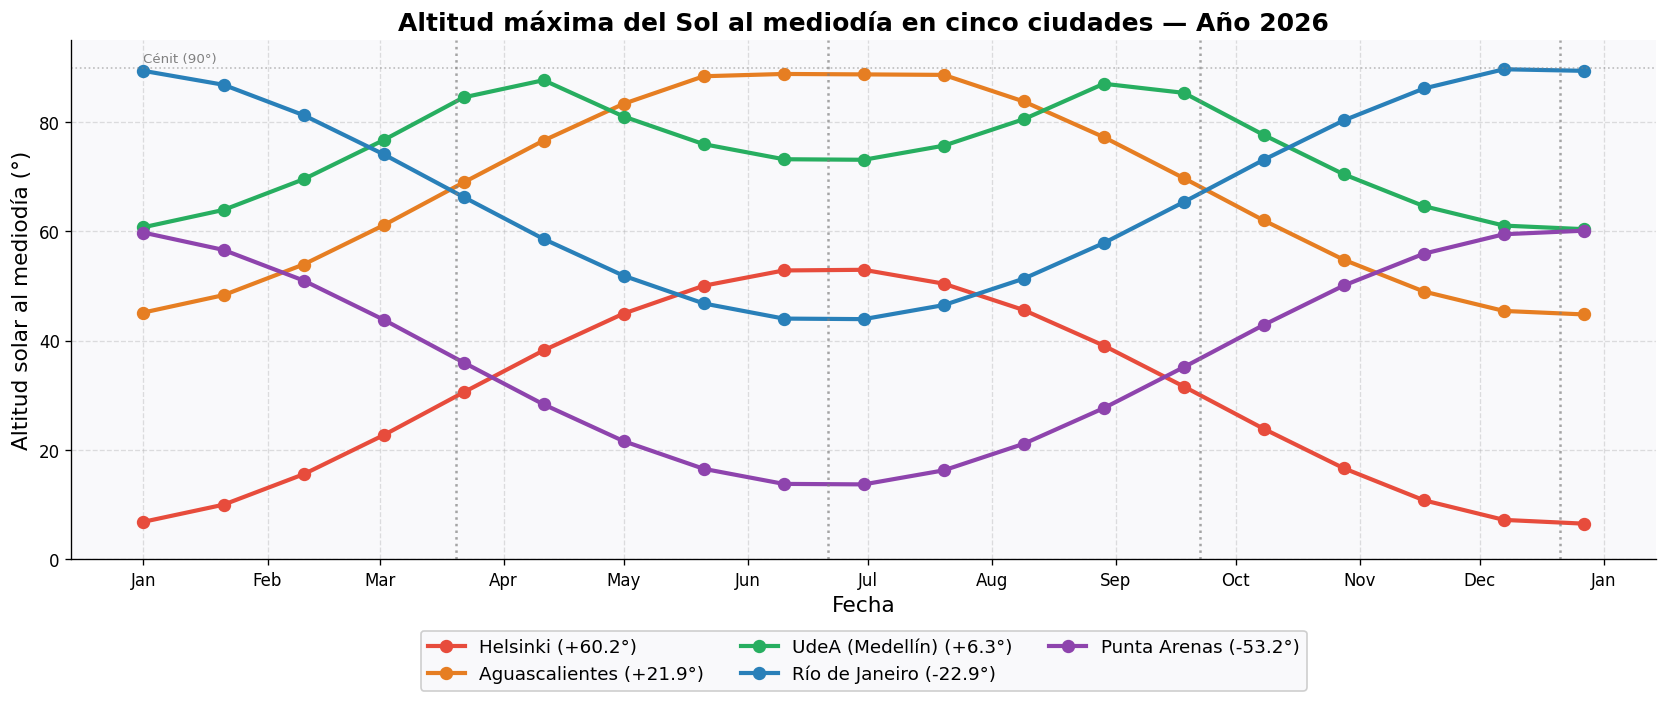

Figura 3 guardada.


In [13]:
# ─── Fig. 3: Altitud al mediodía ──────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

for city in city_keys:
    df    = results[city]
    color = cities_info[city]['color']
    alts  = df['alt_mediodia'].values.astype(float)
    ax.plot(x_dates_dt, alts, 'o-', color=color, lw=2.5, ms=7,
            label=f"{city} ({cities_info[city]['lat']:+.1f}°)")

# Trópicos: altitud máxima al mediodía en el ecuador es 90°
# Latitud φ → alt_max = 90° - |φ - δ|
ax.axhline(90, color='gray', ls=':', lw=1, alpha=0.5)
ax.text(x_dates_dt[0], 91, 'Cénit (90°)', fontsize=8, color='gray')

for dt, label, color in solstices_equinoxes:
    ax.axvline(dt, color='gray', ls=':', lw=1.5, alpha=0.7)

ax.set_xlabel('Fecha', fontsize=13)
ax.set_ylabel('Altitud solar al mediodía (°)', fontsize=13)
ax.set_title('Altitud máxima del Sol al mediodía en cinco ciudades — Año 2026',
             fontsize=15, fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=11, framealpha=0.95)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set_ylim(0, 95)

plt.tight_layout()
plt.savefig('fig3_altitud_mediodia.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 3 guardada.')


### 7.4 Rango de variación de la duración del día

El siguiente diagrama de caja (*box plot*) y la gráfica de barras del rango de variación
muestran **cuánto cambia** la duración del día a lo largo del año en cada ciudad.
Cuanto mayor la latitud absoluta, mayor es la variación.


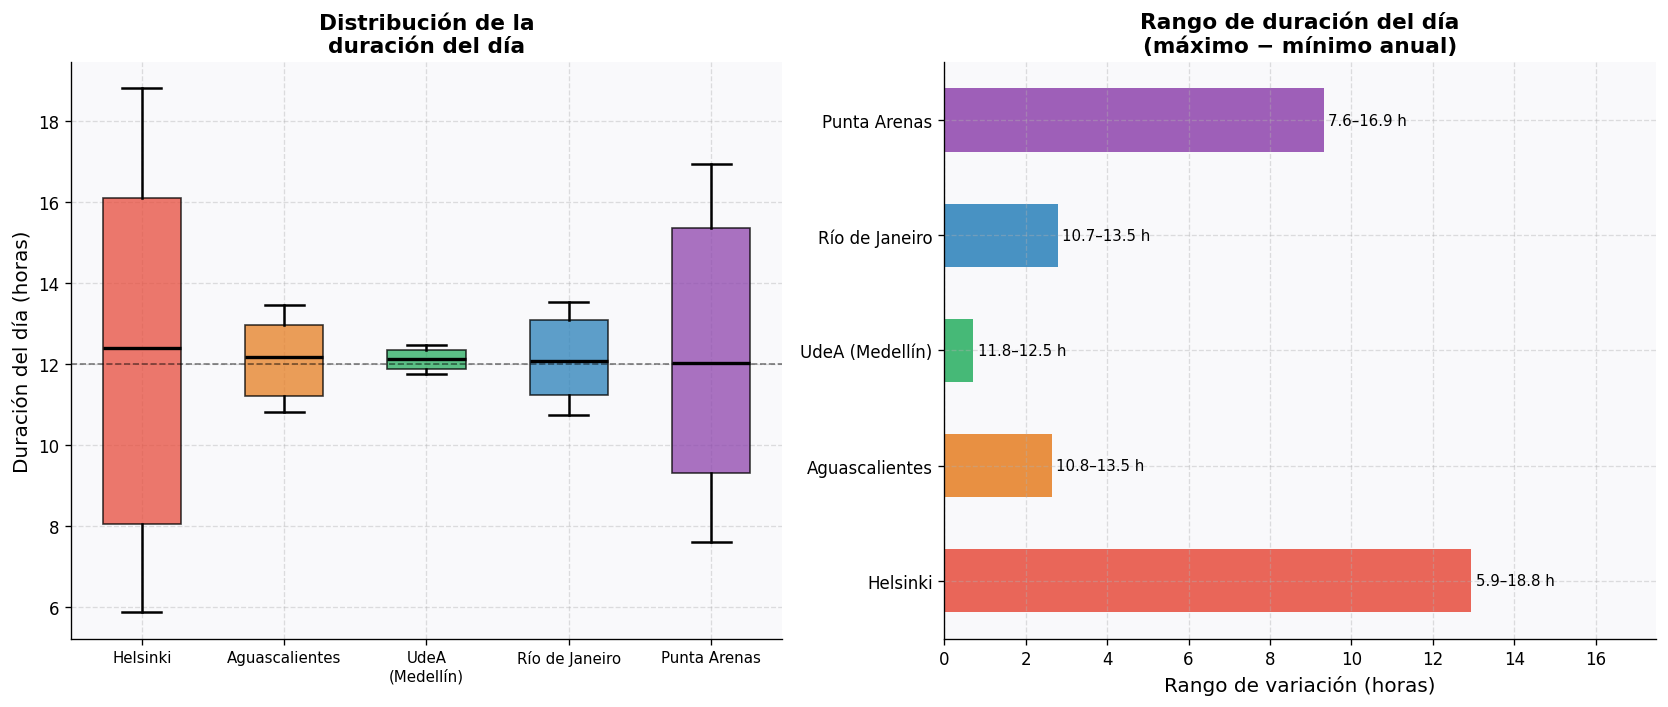

Figura 4 guardada.


In [14]:
# ─── Fig. 4: Variabilidad de la duración del día ──────────────
fig, (ax_box, ax_range) = plt.subplots(1, 2, figsize=(14, 6))

# --- Box plot ---
all_durs = [results[city]['duracion_h'].values.astype(float) for city in city_keys]
bplot = ax_box.boxplot(
    all_durs, labels=[c.replace(' (Medellín)', '\n(Medellín)') for c in city_keys],
    patch_artist=True, notch=False, vert=True, widths=0.55,
    medianprops=dict(color='black', lw=2),
    whiskerprops=dict(lw=1.5),
    capprops=dict(lw=1.5),
)

for patch, city in zip(bplot['boxes'], city_keys):
    patch.set_facecolor(cities_info[city]['color'])
    patch.set_alpha(0.75)

ax_box.axhline(12, color='k', ls='--', lw=1, alpha=0.5)
ax_box.set_ylabel('Duración del día (horas)', fontsize=12)
ax_box.set_title('Distribución de la\nduración del día', fontsize=13, fontweight='bold')
ax_box.tick_params(axis='x', labelsize=9)

# --- Rango (max - min) + latitud ---
lats     = [cities_info[c]['lat']  for c in city_keys]
dur_min  = [np.min(results[c]['duracion_h'].values.astype(float)) for c in city_keys]
dur_max  = [np.max(results[c]['duracion_h'].values.astype(float)) for c in city_keys]
dur_rng  = [mx - mn for mx, mn in zip(dur_max, dur_min)]
colors_l = [cities_info[c]['color'] for c in city_keys]

bars = ax_range.barh(city_keys, dur_rng, color=colors_l, alpha=0.85, height=0.55)
for bar, mn, mx in zip(bars, dur_min, dur_max):
    ax_range.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{mn:.1f}–{mx:.1f} h', va='center', fontsize=9)

ax_range.set_xlabel('Rango de variación (horas)', fontsize=12)
ax_range.set_title('Rango de duración del día\n(máximo − mínimo anual)', fontsize=13, fontweight='bold')
ax_range.set_xlim(0, max(dur_rng) * 1.35)

plt.tight_layout()
plt.savefig('fig4_variabilidad.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 4 guardada.')


### 7.5 Mapa de calor: duración del día por ciudad y mes


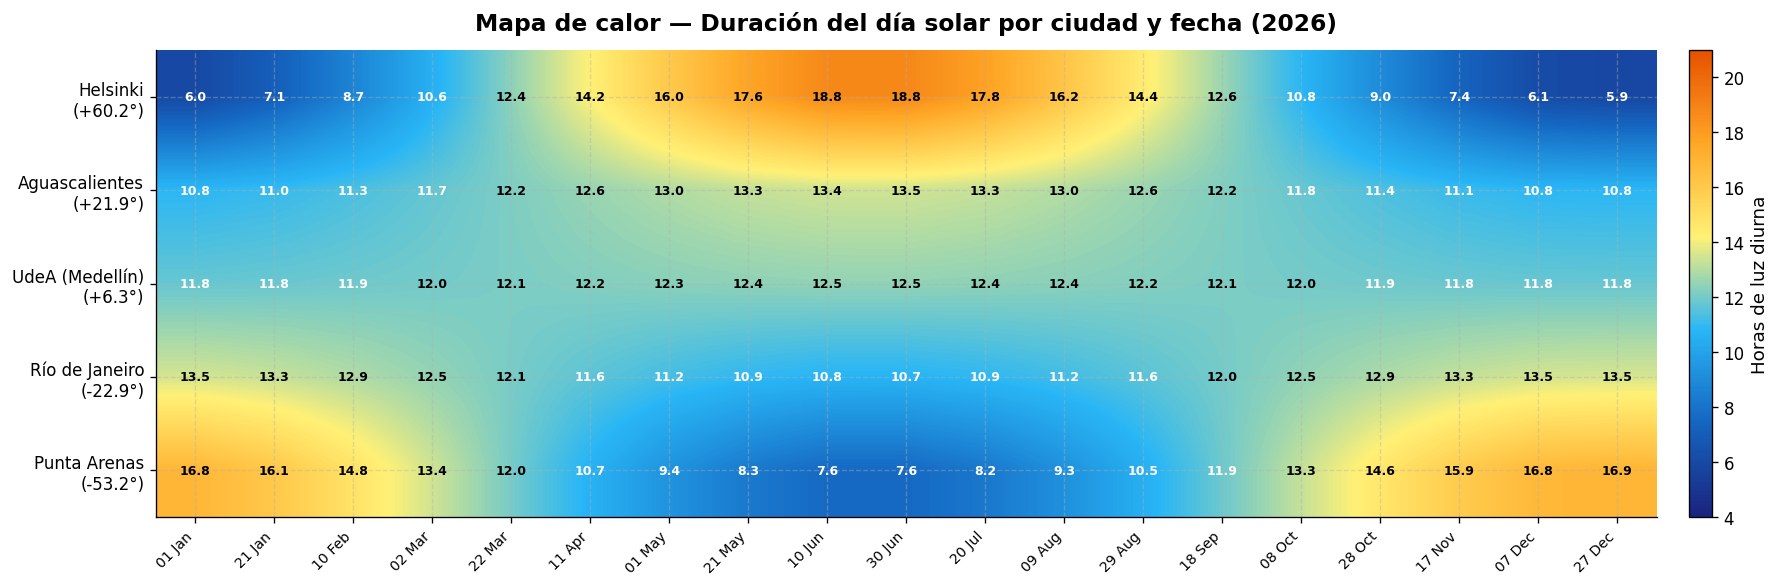

Figura 5 guardada.


In [15]:
# ─── Fig. 5: Mapa de calor ────────────────────────────────────
# Reordenar ciudades de norte a sur para mayor legibilidad
cities_by_lat = sorted(city_keys, key=lambda c: cities_info[c]['lat'], reverse=True)

# Construir matriz: filas = ciudades (norte → sur), columnas = fechas
heat_matrix = np.zeros((len(cities_by_lat), len(x_dates_dt)))
for i, city in enumerate(cities_by_lat):
    heat_matrix[i, :] = results[city]['duracion_h'].values.astype(float)

fig, ax = plt.subplots(figsize=(15, 5))

# Paleta de colores tipo 'día': azul (noche) → amarillo (día)
cmap_custom = LinearSegmentedColormap.from_list(
    'day_night', ['#1a237e', '#1565c0', '#29b6f6', '#fff176', '#ffa726', '#e65100'], N=256
)

im = ax.imshow(heat_matrix, aspect='auto', cmap=cmap_custom,
               vmin=4, vmax=21, interpolation='bilinear')

# Etiquetas de ejes
ax.set_xticks(range(len(x_dates_dt)))
ax.set_xticklabels([d.strftime('%d %b') for d in x_dates_dt],
                   rotation=45, ha='right', fontsize=8.5)
ax.set_yticks(range(len(cities_by_lat)))
ax.set_yticklabels([f"{c}\n({cities_info[c]['lat']:+.1f}°)" for c in cities_by_lat], fontsize=10)

# Anotaciones de valor en cada celda
for i in range(len(cities_by_lat)):
    for j in range(len(x_dates_dt)):
        val = heat_matrix[i, j]
        ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                fontsize=7.5, color='white' if val < 12 else 'black', fontweight='bold')

# Barra de color
cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label('Horas de luz diurna', fontsize=11)

ax.set_title('Mapa de calor — Duración del día solar por ciudad y fecha (2026)',
             fontsize=14, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('fig5_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 5 guardada.')


## 8. Análisis y Conclusiones

### 8.1 Comparación entre hemisferios

Las figuras anteriores evidencian que **Helsinki** (HN, +60°) y **Punta Arenas** (HS, −54°)
experimentan variaciones extremas, pero **en oposición de fase**: cuando Helsinki tiene su
día más largo (~19 h, solsticio de junio), Punta Arenas tiene su día más corto (~7,5 h),
y viceversa en diciembre. Este comportamiento antisimétrico respecto a la línea de 12 h es
la consecuencia directa de la **inclinación axial de 23,44°** de la Tierra: el eje de rotación
apunta siempre hacia el mismo punto de la esfera celeste (cerca de Polaris), de modo que en
junio el Polo Norte está inclinado *hacia* el Sol (verano boreal = invierno austral) y en
diciembre lo está el Polo Sur.

### 8.2 Latitudes tropicales (Medellín y Aguascalientes)

La **Universidad de Antioquia** (φ ≈ +6°) presenta una variación anual de apenas
~0,6 h (~36 min) entre el día más corto y el más largo: algo perfectamente observable
si uno presta atención, pero que en la vida cotidiana pasa desapercibido. Esto confirma
que en Colombia *hay* un ciclo diurno anual, aunque muy atenuado.

**Aguascalientes** (+21,9°) muestra una variación de ~3 h, notablemente mayor que la de
Medellín pero mucho menor que la de Helsinki: la variación aumenta con la latitud de manera
no lineal, conforme a la fórmula del ángulo horario de salida/puesta.

### 8.3 La relación con las estaciones

Las estaciones del año *no se deben a la distancia Tierra-Sol* (la Tierra está más cerca
del Sol en enero, en perihelio, que en julio). Se deben exclusivamente a la **inclinación
del eje** terrestre, que determina:

1. La *duración del día* (horas de insolación directa).
2. El *ángulo de incidencia* de los rayos solares (a mayor altitud del Sol, mayor
   intensidad por unidad de área).

Ambos efectos combinados producen el exceso de calor en verano y el déficit en invierno
en las latitudes medias.

### 8.4 Respuestas a las preguntas guía

**¿Cómo se compara la duración del día en los hemisferios?**
Son imágenes especulares en el tiempo: cuando el hemisferio norte tiene su máximo de luz,
el hemisferio sur tiene su mínimo. Los valores extremos dependen de la latitud; cerca del
ecuador ambos hemisferios convergen a ~12 h todo el año.

**¿Cómo se relacionan las horas de salida/puesta con la época del año?**
En el hemisferio norte, el Sol sale más temprano y se oculta más tarde a medida que nos
acercamos al solsticio de junio (días más largos). En diciembre ocurre lo contrario. Para
Medellín, los cambios son sutiles (~12 min adelanto/retraso en el amanecer), pero reales.

**¿Cómo se explica?**
La Tierra orbita al Sol con el eje inclinado 23,44° respecto a la perpendicular del plano
orbital. Esto hace que la declinación solar varíe entre +23,44° y −23,44°, modulando
tanto la duración del día como la intensidad de la radiación solar recibida en cada latitud.


---

## 9. 🌍 Visualización Astronómica Especial: La Tierra y las Estaciones

A continuación se presentan dos figuras complementarias que muestran el contexto astronómico
de toda la práctica: la órbita de la Tierra alrededor del Sol y la distribución del terminador
solar (línea de separación entre día y noche) en las cuatro fechas clave del año.


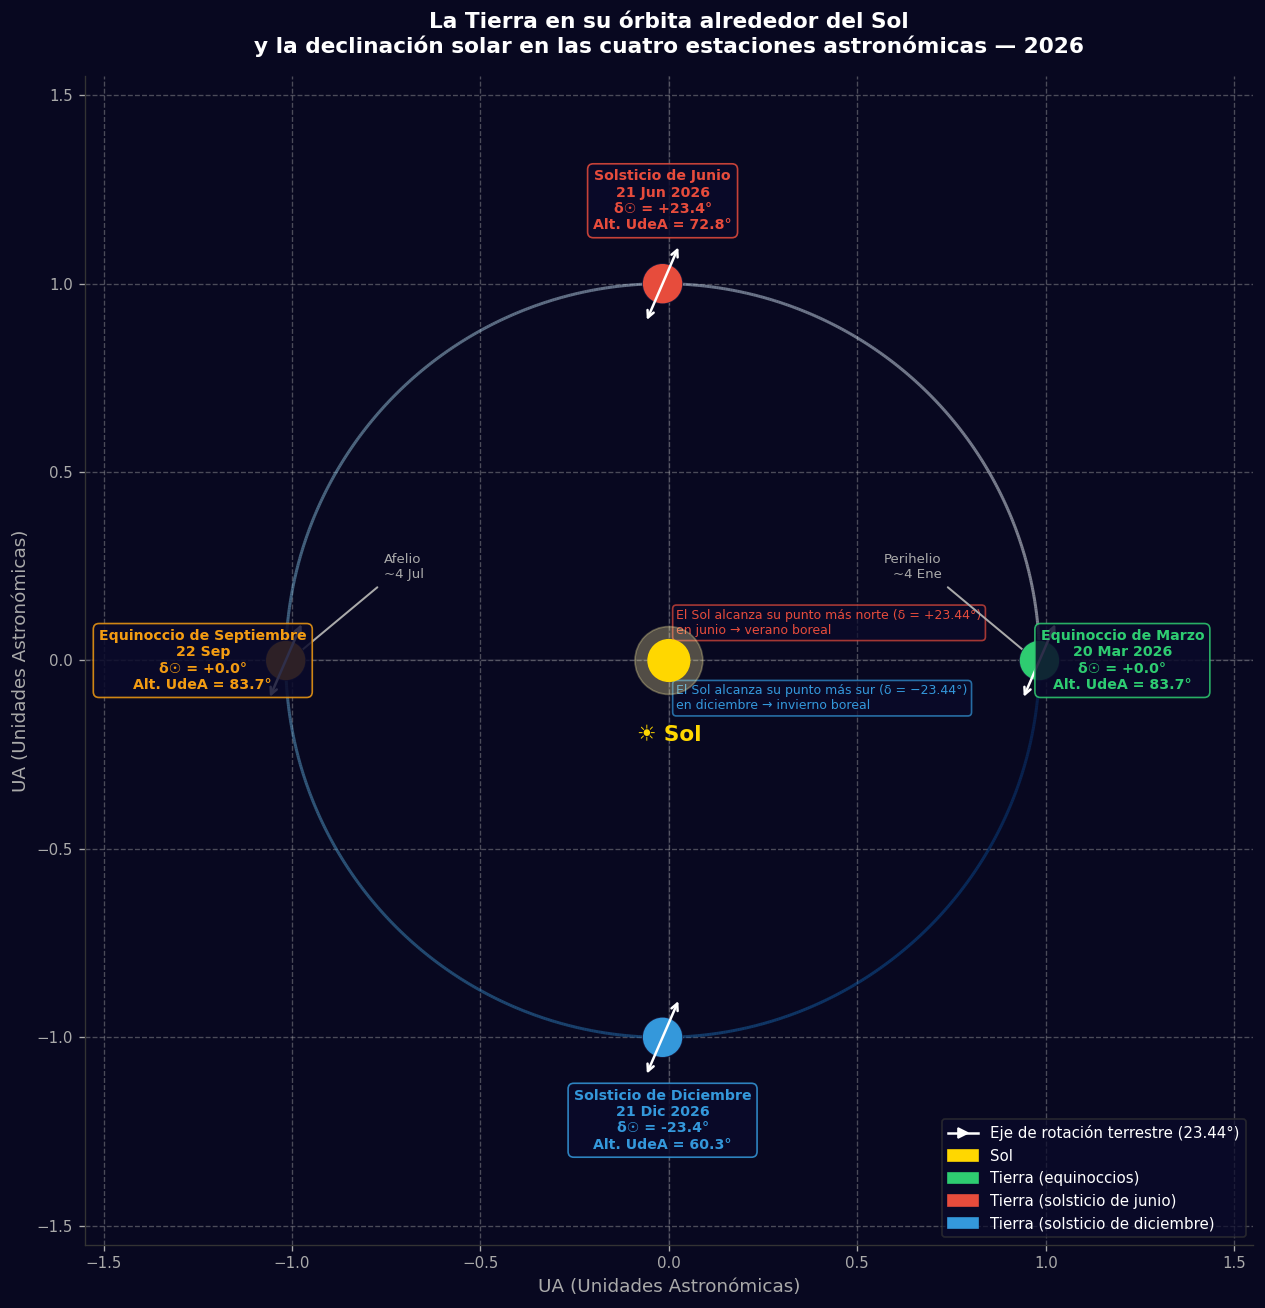

Figura 6 guardada.


In [16]:
# ─── Fig. 6: Diagrama orbital 2D con la Tierra en las cuatro estaciones ──────
fig, ax = plt.subplots(figsize=(11, 11))
fig.patch.set_facecolor('#080820')
ax.set_facecolor('#080820')

# Órbita elíptica (excentricidad real de la Tierra ≈ 0.0167, amplificada visualmente)
a = 1.0      # semieje mayor (UA)
e = 0.0167   # excentricidad real
b = a * np.sqrt(1 - e**2)
f = a * e    # distancia foco-centro

theta = np.linspace(0, 2*np.pi, 1000)
x_orb = a * np.cos(theta) - f
y_orb = b * np.sin(theta)

# Degradado de la órbita
from matplotlib.collections import LineCollection
points  = np.array([x_orb, y_orb]).T.reshape(-1, 1, 2)
segs    = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segs, cmap='Blues', linewidths=1.8, alpha=0.5)
lc.set_array(np.linspace(0, 1, len(segs)))
ax.add_collection(lc)

# Sol
sun_glow = plt.Circle((0, 0), 0.09, color='#FFF0A0', zorder=8, alpha=0.3)
sun_core = plt.Circle((0, 0), 0.055, color='#FFD700', zorder=9)
ax.add_patch(sun_glow)
ax.add_patch(sun_core)
ax.text(0, -0.17, '☀ Sol', ha='center', va='top', fontsize=13, color='#FFD700',
        fontweight='bold', zorder=10)

# Estaciones (ángulos heliocéntricos aproximados para 2026)
# Perihelio ~4 ene, solsticio jun ~21 jun (~167° desde perihelio), etc.
season_data = [
    ('Equinoccio de Marzo\n20 Mar 2026',   0.0,   '#2ecc71'),
    ('Solsticio de Junio\n21 Jun 2026',    90.0,  '#e74c3c'),
    ('Equinoccio de Septiembre\n22 Sep',   180.0, '#f39c12'),
    ('Solsticio de Diciembre\n21 Dic 2026',270.0, '#3498db'),
]

# Declinación solar y altitud UdeA al mediodía para cada estación
decl_vals  = [0.0, 23.44, 0.0, -23.44]
udea_lat   = 6.2678
udea_alt   = [90 - abs(udea_lat - d) for d in decl_vals]

for (label, angle_deg, color), decl, u_alt in zip(season_data, decl_vals, udea_alt):
    rad = np.radians(angle_deg)
    x_e = a * np.cos(rad) - f
    y_e = b * np.sin(rad)

    # Tierra con gradiente día/noche (simple bicolor)
    night = plt.Circle((x_e, y_e), 0.052, color='#1a1a3e', zorder=11)
    day   = plt.Circle((x_e, y_e), 0.050, color=color,       zorder=12)
    ax.add_patch(night)
    ax.add_patch(day)

    # Eje de rotación inclinado
    tilt_deg  = 23.44
    tilt_rad  = np.radians(tilt_deg)
    ax_len    = 0.105
    dx_ax     = ax_len * np.sin(tilt_rad)
    dy_ax     = ax_len * np.cos(tilt_rad)
    ax.annotate('', xy=(x_e + dx_ax, y_e + dy_ax), xytext=(x_e - dx_ax, y_e - dy_ax),
                arrowprops=dict(arrowstyle='<->', color='white', lw=1.5, shrinkA=0, shrinkB=0),
                zorder=13)

    # Etiqueta
    offset = 0.22
    lx = x_e + offset * np.cos(rad)
    ly = y_e + offset * np.sin(rad)
    label_full = f'{label}\nδ☉ = {decl:+.1f}°\nAlt. UdeA = {u_alt:.1f}°'
    ax.text(lx, ly, label_full, ha='center', va='center', fontsize=8.5,
            color=color, fontweight='bold', zorder=14,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#0a0a2a', alpha=0.85, edgecolor=color))

# Trópico de Cáncer / Capricornio labels
ax.text(0.02, 0.10, 'El Sol alcanza su punto más norte (δ = +23.44°)\nen junio → verano boreal',
        color='#e74c3c', fontsize=7.5, va='center',
        bbox=dict(facecolor='#0a0a2a', edgecolor='#e74c3c', alpha=0.7, boxstyle='round'))

ax.text(0.02, -0.10, 'El Sol alcanza su punto más sur (δ = −23.44°)\nen diciembre → invierno boreal',
        color='#3498db', fontsize=7.5, va='center',
        bbox=dict(facecolor='#0a0a2a', edgecolor='#3498db', alpha=0.7, boxstyle='round'))

# Línea del ecuador celeste (plano de referencia)
ax.axhline(0, color='white', alpha=0.08, lw=1)
ax.axvline(0, color='white', alpha=0.08, lw=1)

# Indicar perihelio y afelio
ax.annotate('', xy=(-a - f + 0.01, 0), xytext=(-a - f + 0.25, 0.2),
            arrowprops=dict(arrowstyle='->', color='#aaa', lw=1.2))
ax.text(-a - f + 0.26, 0.22, 'Afelio\n~4 Jul', color='#aaa', fontsize=8)

ax.annotate('', xy=(a - f - 0.01, 0), xytext=(a - f - 0.25, 0.2),
            arrowprops=dict(arrowstyle='->', color='#aaa', lw=1.2))
ax.text(a - f - 0.26, 0.22, 'Perihelio\n~4 Ene', color='#aaa', fontsize=8, ha='right')

ax.set_xlim(-1.55, 1.55)
ax.set_ylim(-1.55, 1.55)
ax.set_aspect('equal')
ax.tick_params(colors='#aaa', labelsize=9)
for spine in ax.spines.values():
    spine.set_color('#333')

ax.set_xlabel('UA (Unidades Astronómicas)', color='#aaa', fontsize=11)
ax.set_ylabel('UA (Unidades Astronómicas)', color='#aaa', fontsize=11)
ax.set_title('La Tierra en su órbita alrededor del Sol\n'
             'y la declinación solar en las cuatro estaciones astronómicas — 2026',
             color='white', fontsize=13, fontweight='bold', pad=14)

# Leyenda del eje de rotación
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='white', lw=1.5, marker='>', label='Eje de rotación terrestre (23.44°)'),
    mpatches.Patch(color='#FFD700', label='Sol'),
    mpatches.Patch(color='#2ecc71', label='Tierra (equinoccios)'),
    mpatches.Patch(color='#e74c3c', label='Tierra (solsticio de junio)'),
    mpatches.Patch(color='#3498db', label='Tierra (solsticio de diciembre)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, framealpha=0.7,
          facecolor='#0a0a2a', labelcolor='white', edgecolor='#333')

plt.tight_layout()
plt.savefig('fig6_orbita_tierra.png', dpi=150, bbox_inches='tight', facecolor='#080820')
plt.show()
print('Figura 6 guardada.')

### 9.2 Terminador solar — La Tierra en las cuatro estaciones

El **terminador** es la línea que separa el hemisferio iluminado (día) del oscuro (noche).
Su orientación en el globo terrestre depende directamente de la **declinación solar** del momento.
En los equinoccios, el terminador pasa exactamente por los polos y la duración del día es
~12 h en toda la Tierra. En los solsticios, el terminador está inclinado 23,44° respecto a
los meridianos, lo que genera días extremadamente largos cerca del polo apuntando al Sol
y noches polares en el polo opuesto.

Las estrellas amarillas (⭐) marcan el **punto subsolar** (donde el Sol está en el cénit).
Los triángulos rojos (▲) marcan la ubicación de **Medellín, Colombia**.


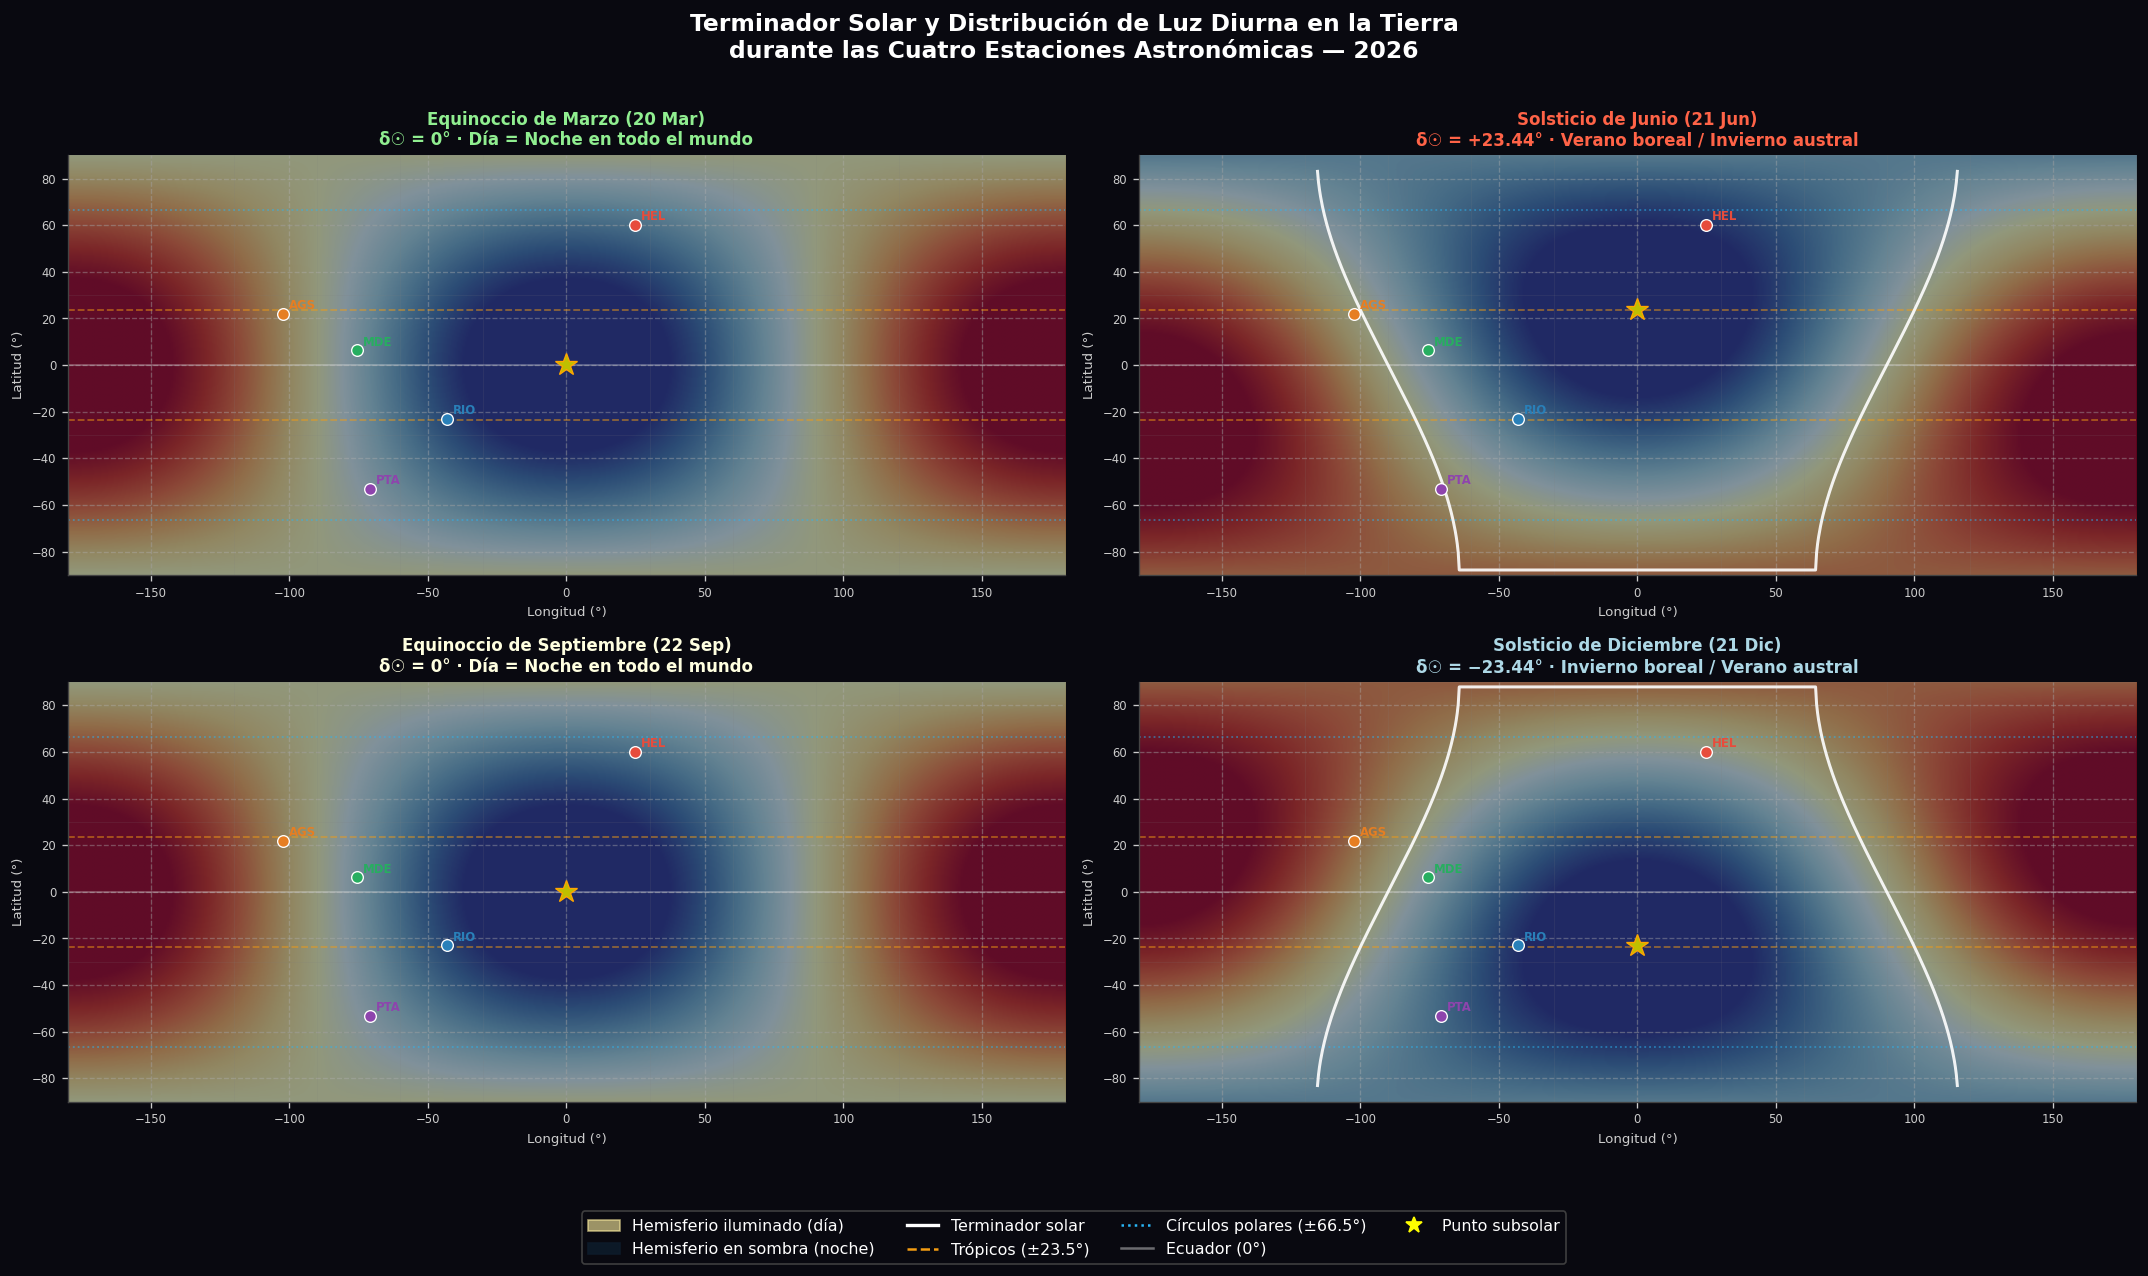

Figura 7 guardada.


In [18]:
# ─── Fig. 7: Terminador solar en las cuatro estaciones ───────

def draw_earth_with_cities(ax, sub_solar_lat_deg, sub_solar_lon_deg, title, t_color):
    """
    Dibuja el mapa de día/noche con el terminador solar y ciudades del estudio.
    """
    lon_g = np.linspace(-180, 180, 720)
    lat_g = np.linspace(-90, 90, 360)
    LON, LAT = np.meshgrid(lon_g, lat_g)

    ssl = np.radians(sub_solar_lat_deg)
    sso = np.radians(sub_solar_lon_deg)
    lat_r = np.radians(LAT)
    lon_r = np.radians(LON)

    cos_z = (np.sin(ssl) * np.sin(lat_r) +
             np.cos(ssl) * np.cos(lat_r) * np.cos(lon_r - sso))

    # Fondo nocturno
    ax.set_facecolor('#0d1b2a')

    # Día/noche con suavizado
    ax.imshow(np.clip(cos_z[::-1], -1, 1),
              extent=[-180, 180, -90, 90], cmap='RdYlBu',
              vmin=-0.8, vmax=0.8, alpha=0.55, aspect='auto', interpolation='bilinear')

    # Terminator line
    term_lats = []
    term_lons = []
    for lo in np.linspace(-180, 180, 1000):
        lo_r = np.radians(lo)
        # cos_z = 0  → sin(ssl)*sin(la_r) + cos(ssl)*cos(la_r)*cos(lo_r - sso) = 0
        # sin(la_r) = -cos(ssl)*cos(lo_r-sso) / sin(ssl) only if sin(ssl) ≠ 0
        if abs(sub_solar_lat_deg) > 0.01:
            val = -np.cos(ssl) * np.cos(lo_r - sso) / np.sin(ssl)
            if abs(val) <= 1:
                la = np.degrees(np.arcsin(val))
                term_lats.append(la)
                term_lons.append(lo)

    if term_lons:
        # Sort by longitude for clean line
        pairs = sorted(zip(term_lons, term_lats))
        tl, ta = zip(*pairs)
        ax.plot(tl, ta, 'w-', lw=1.8, alpha=0.9, zorder=5)

    # Cuadrículas
    for lo in range(-180, 181, 30):
        ax.axvline(lo, color='gray', alpha=0.15, lw=0.5)
    for la in range(-90, 91, 30):
        ax.axhline(la, color='gray', alpha=0.15, lw=0.5)

    # Líneas especiales
    ax.axhline(23.5,  color='#f39c12', alpha=0.5, lw=1.1, ls='--')   # Trópico Cáncer
    ax.axhline(-23.5, color='#f39c12', alpha=0.5, lw=1.1, ls='--')   # Trópico Capricornio
    ax.axhline(66.5,  color='#29b6f6', alpha=0.5, lw=1.1, ls=':')    # Cír. Polar N
    ax.axhline(-66.5, color='#29b6f6', alpha=0.5, lw=1.1, ls=':')    # Cír. Polar S
    ax.axhline(0,     color='white',   alpha=0.3, lw=1.0)             # Ecuador

    # Punto subsolar
    ax.plot(sub_solar_lon_deg, sub_solar_lat_deg, 'y*', ms=14, zorder=10,
            markeredgecolor='orange', markeredgewidth=0.8)

    # Ciudades del estudio
    city_points = {
        'HEL': (24.94,   60.17,  cities_info['Helsinki']['color']),
        'AGS': (-102.29, 21.89,  cities_info['Aguascalientes']['color']),
        'MDE': (-75.57,  6.27,   cities_info['UdeA (Medellín)']['color']),
        'RIO': (-43.17, -22.91,  cities_info['Río de Janeiro']['color']),
        'PTA': (-70.92, -53.16,  cities_info['Punta Arenas']['color']),
    }
    for code, (lo, la, c) in city_points.items():
        ax.plot(lo, la, 'o', color=c, ms=7, zorder=9, markeredgecolor='white', markeredgewidth=0.8)
        ax.text(lo + 2, la + 2, code, color=c, fontsize=7, fontweight='bold', zorder=10)

    ax.set_title(title, color=t_color, fontsize=10, fontweight='bold')
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    ax.tick_params(colors='#ccc', labelsize=7)
    for spine in ax.spines.values():
        spine.set_color('#444')
    ax.set_xlabel('Longitud (°)', color='#ccc', fontsize=8)
    ax.set_ylabel('Latitud (°)',  color='#ccc', fontsize=8)


fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.patch.set_facecolor('#090910')

draw_earth_with_cities(axes[0, 0], 0.0,    0,
    'Equinoccio de Marzo (20 Mar)\nδ☉ = 0° · Día = Noche en todo el mundo', 'lightgreen')
draw_earth_with_cities(axes[0, 1], 23.44,  0,
    'Solsticio de Junio (21 Jun)\nδ☉ = +23.44° · Verano boreal / Invierno austral', 'tomato')
draw_earth_with_cities(axes[1, 0], 0.0,    0,
    'Equinoccio de Septiembre (22 Sep)\nδ☉ = 0° · Día = Noche en todo el mundo', 'lightyellow')
draw_earth_with_cities(axes[1, 1], -23.44, 0,
    'Solsticio de Diciembre (21 Dic)\nδ☉ = −23.44° · Invierno boreal / Verano austral', 'lightblue')

# Leyenda global
from matplotlib.lines import Line2D
legend_elements = [
    mpatches.Patch(color='#FFF0A0', alpha=0.6, label='Hemisferio iluminado (día)'),
    mpatches.Patch(color='#0d1b2a', alpha=0.9, label='Hemisferio en sombra (noche)'),
    Line2D([0], [0], color='white', lw=2,  label='Terminador solar'),
    Line2D([0], [0], color='#f39c12', lw=1.5, ls='--', label='Trópicos (±23.5°)'),
    Line2D([0], [0], color='#29b6f6', lw=1.5, ls=':',  label='Círculos polares (±66.5°)'),
    Line2D([0], [0], color='white',   lw=1.5, alpha=0.4, label='Ecuador (0°)'),
    Line2D([0], [0], marker='*', color='yellow', ms=10, lw=0, label='Punto subsolar'),
]

fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=9.5,
           facecolor='#090910', labelcolor='white', edgecolor='#444', framealpha=0.9,
           bbox_to_anchor=(0.5, -0.04))

plt.suptitle('Terminador Solar y Distribución de Luz Diurna en la Tierra\n'
             'durante las Cuatro Estaciones Astronómicas — 2026',
             color='white', fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('fig7_terminador.png', dpi=150, bbox_inches='tight', facecolor='#090910')
plt.show()
print('Figura 7 guardada.')


---

## 10. Referencias

Carroll, B. W., & Ostlie, D. A. (2017). *An introduction to modern astrophysics* (2nd ed.). Cambridge University Press. https://doi.org/10.1017/9781108380980

Giorgini, J. D., Yeomans, D. K., Chamberlin, A. B., Chodas, P. W., Jacobson, R. A., Keesey, M. S., Lieske, J. H., Ostro, S. J., Standish, E. M., & Wimberly, R. N. (1996). JPL's On-Line Solar System Data Service. *Bulletin of the American Astronomical Society*, *28*, 1158. https://ui.adsabs.harvard.edu/abs/1996DPS....28.2504G

Ginsburg, A., Sipőcz, B. M., Brasseur, C. E., Cowperthwaite, P. S., Craig, M. W., Deil, C., Guillochon, J., Guzman, G., Liedtke, S., Lim, P. L., Lockhart, K. E., Mommert, M., Morris, B. M., Norman, H., Parikh, M., Perley, D. A., Robitaille, T. P., Sherbert, K., Sherry, W., … Astropy Collaboration. (2019). astroquery: An astronomical web-querying package in Python. *The Astronomical Journal*, *157*(3), 98. https://doi.org/10.3847/1538-3881/aafc33

IDEAM (Instituto de Hidrología, Meteorología y Estudios Ambientales). (2014). *Atlas climatológico de Colombia*. IDEAM. https://www.ideam.gov.co

Meeus, J. (1998). *Astronomical algorithms* (2nd ed.). Willmann-Bell.

Morris, B. M., Tollerud, E., Sipőcz, B., Deil, C., Douglas, S. T., Berlanga Medina, J., Vyhmeister, K., Smith, T. R., Littlefair, S., Price-Whelan, A. M., Gee, W. T., & Jeschke, E. (2018). astroplan: An open source observation planning package in Python. *The Astronomical Journal*, *155*(3), 128. https://doi.org/10.3847/1538-3881/aaa47e

NASA Jet Propulsion Laboratory. (2026). *JPL Horizons On-Line Ephemeris System* (versión 4.x) [Software]. https://ssd.jpl.nasa.gov/horizons/

Price-Whelan, A. M., Sipőcz, B. M., Günther, H. M., et al. (2018). The Astropy project: Building an open-science project and status of the v2.0 core package. *The Astronomical Journal*, *156*(3), 123. https://doi.org/10.3847/1538-3881/aabc4f

---

> *Notebook generado como parte de la Práctica 5 del curso Introducción a la Astronomía Práctica,  
> Universidad de Antioquia. Todos los cálculos son reproducibles en Google Colab.*
